# Phase 9 - Chapter IV Reporting

This notebook regenerates full-data tables, figures, and the results-and-discussion draft. Quick-run metrics are rejected by the reporting module.

In [1]:
# Cell 1 - Locate the project root and import notebook dependencies.
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

project_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'configs' / 'config.yaml').exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

config_path = project_root / 'configs' / 'config.yaml'
report_dir = project_root / 'reports' / 'phase9'
print(f'Project root: {project_root}')

Project root: e:\Paper Multiclass-Intrusion-Detection-System


In [2]:
# Cell 2 - Generate the canonical Phase 9 report package from full-data artifacts.
from src.reporting import generate_phase9_report

report_result = generate_phase9_report(
    config_path=config_path,
    output_dir=report_dir,
)

print(f"Draft: {report_result['draft_path']}")
print(f"Manifest: {report_result['manifest_path']}")

Draft: e:\Paper Multiclass-Intrusion-Detection-System\reports\phase9\chapter4_results_and_discussion.md
Manifest: e:\Paper Multiclass-Intrusion-Detection-System\reports\phase9\report_manifest.json


In [3]:
# Cell 3 - Review the full-data aggregate scenario table used in Chapter IV.
scenario_columns = [
    'scenario_label',
    'accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'training_seconds',
]
report_result['summary'][scenario_columns]

,scenario_label,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,S1 - No handling,0.843600,0.320398,0.337571,0.314168,104.975497
1,S2 - Class weight,0.728500,0.410582,0.562000,0.424949,104.912774
2,S3 - Upsampling,0.727819,0.410291,0.557990,0.423284,532.179907
3,S4 - Downsampling,0.615504,0.305047,0.490024,0.292287,1.636508


In [4]:
# Cell 4 - Review the evidence-based H1-H3 conclusions.
report_result['hypothesis_table']

,hypothesis,assessment,evidence
0,H1,Supported methodologically,Split precedes normalization; scaler scope is ...
1,H2,Partially supported,Latent-16 reduces dimension by 76.81% and rema...
2,H3,Supported,"S1 has the best accuracy, while S2 has the bes..."


### Figure 4.1 - Autoencoder Training and Validation Loss

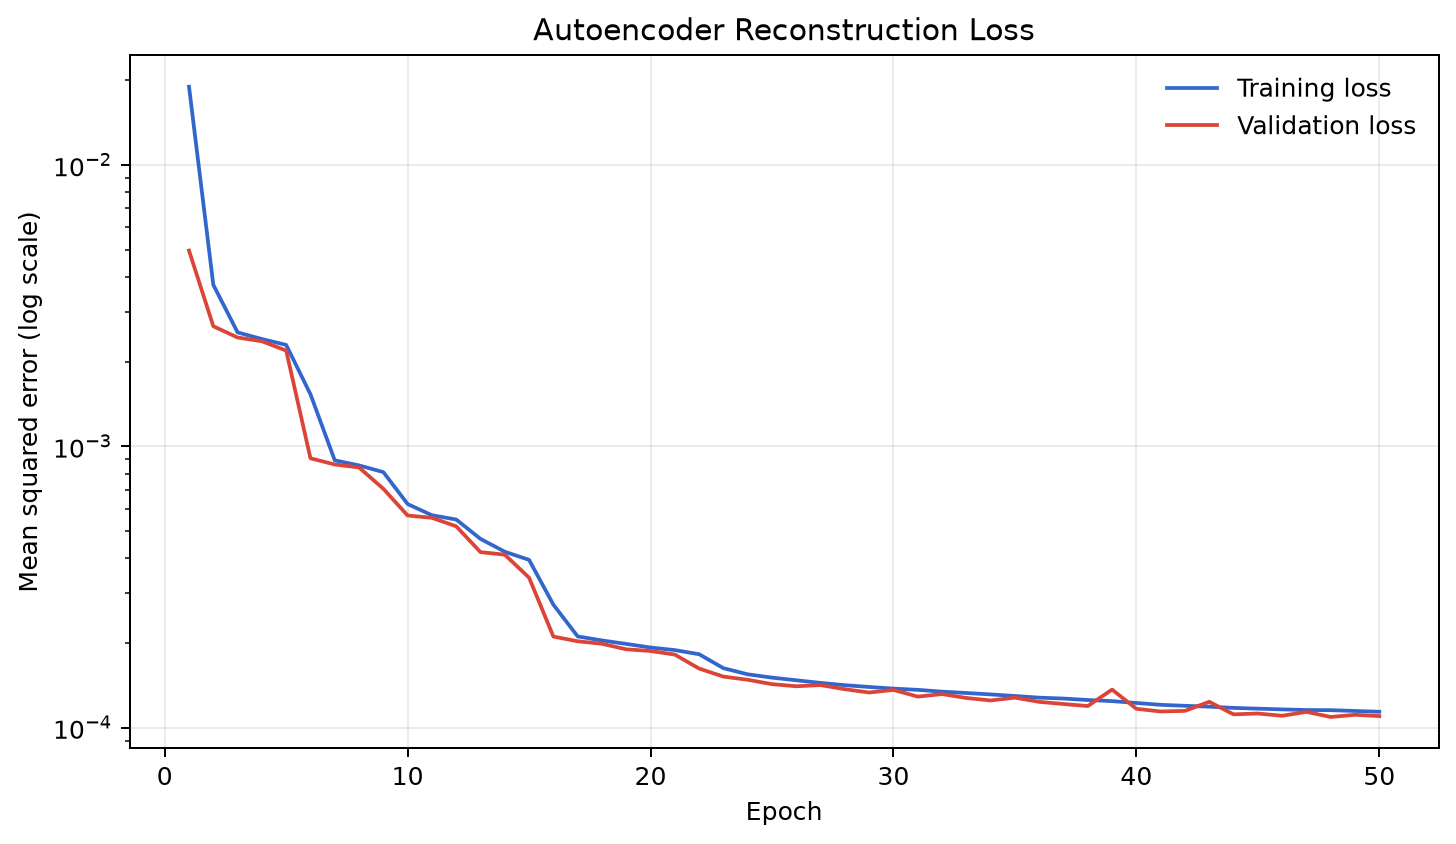

### Figure 4.2 - Aggregate Scenario Metrics

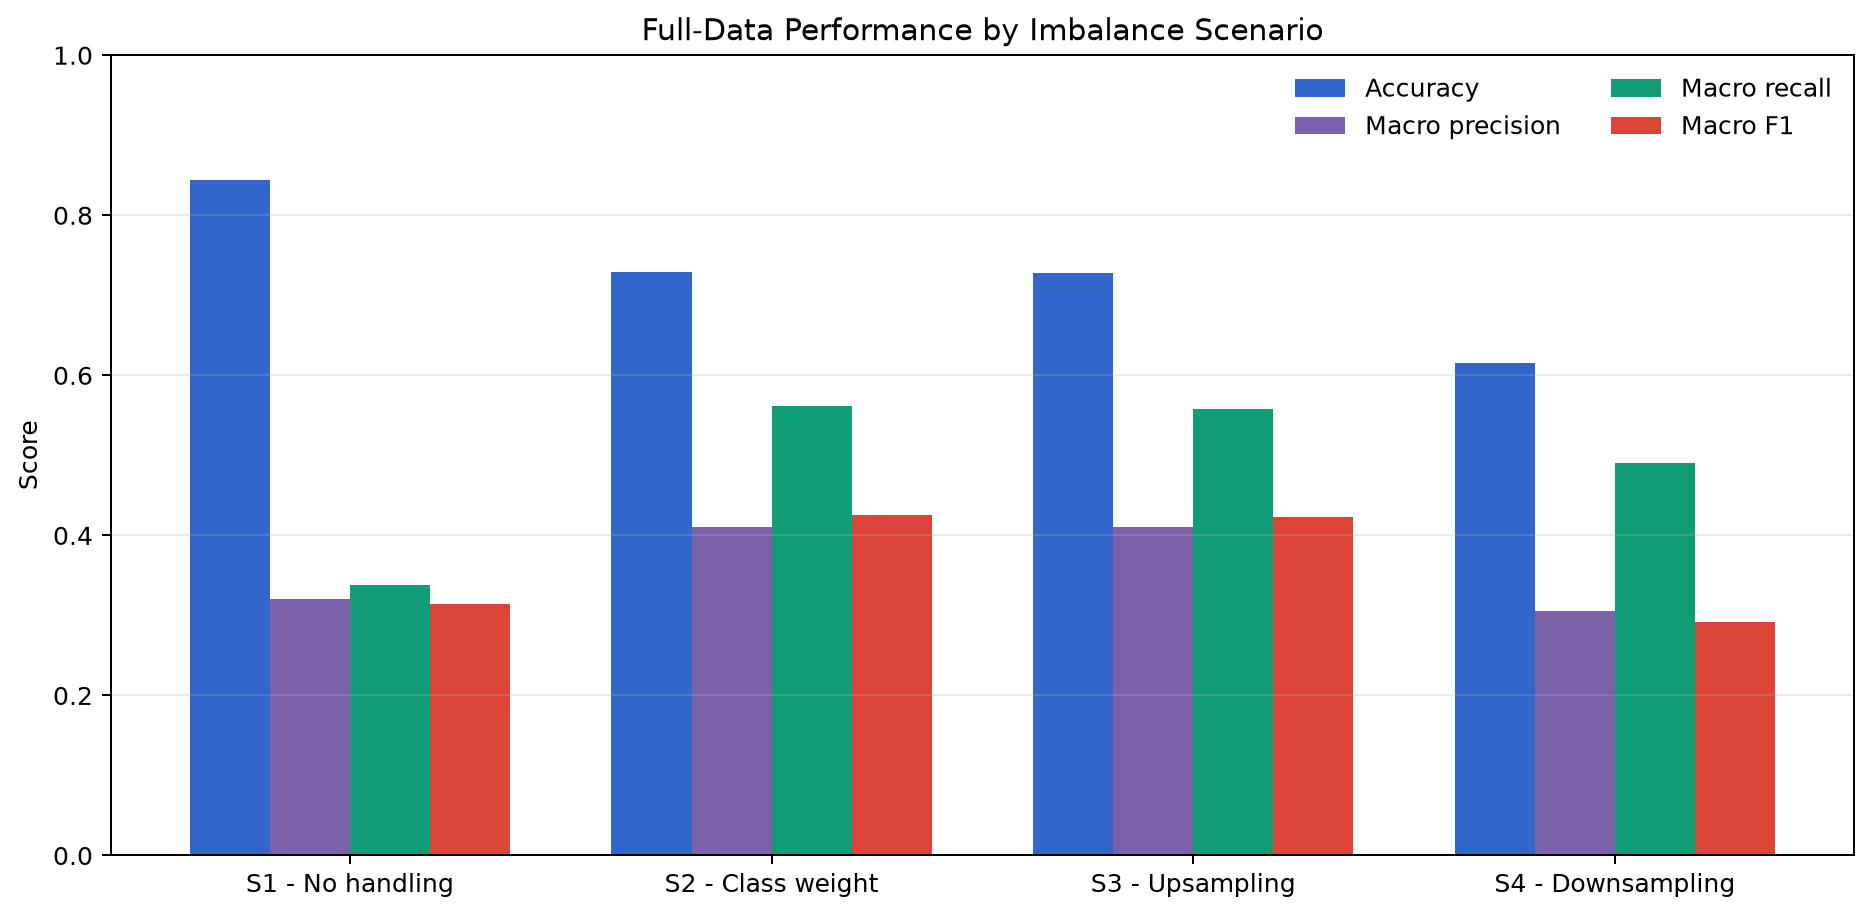

### Figure 4.3 - Minority-Class F1-Scores

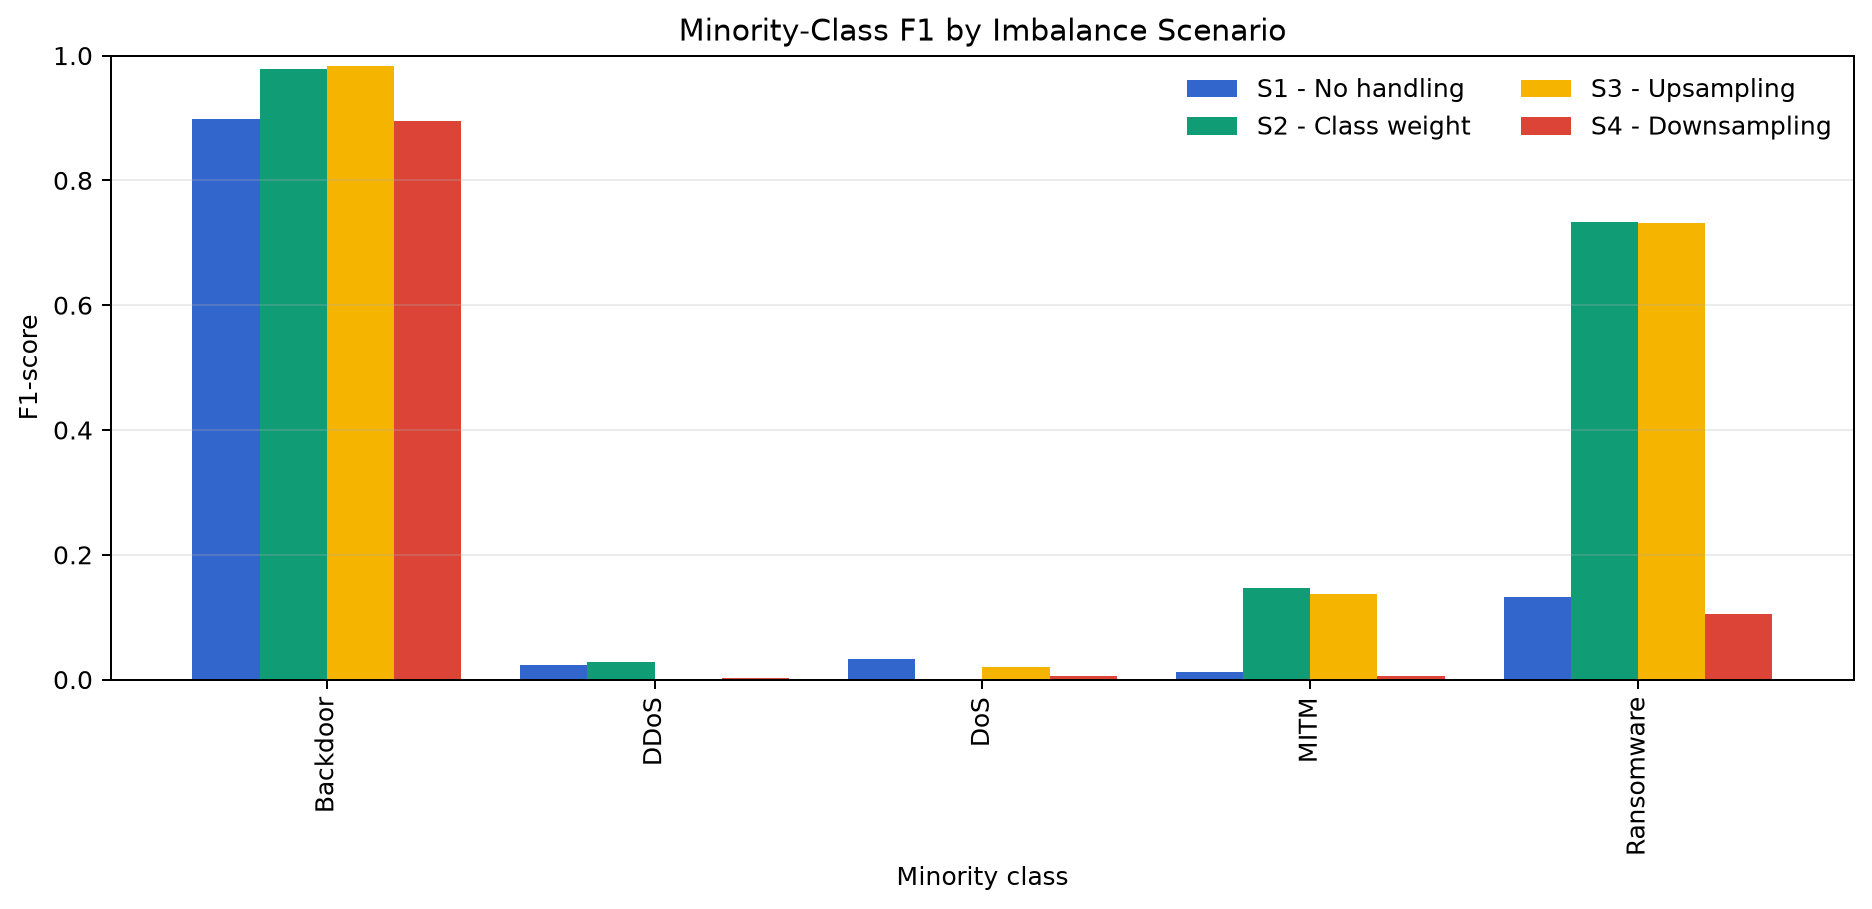

### Figure 4.4 - S2 Confusion Matrix

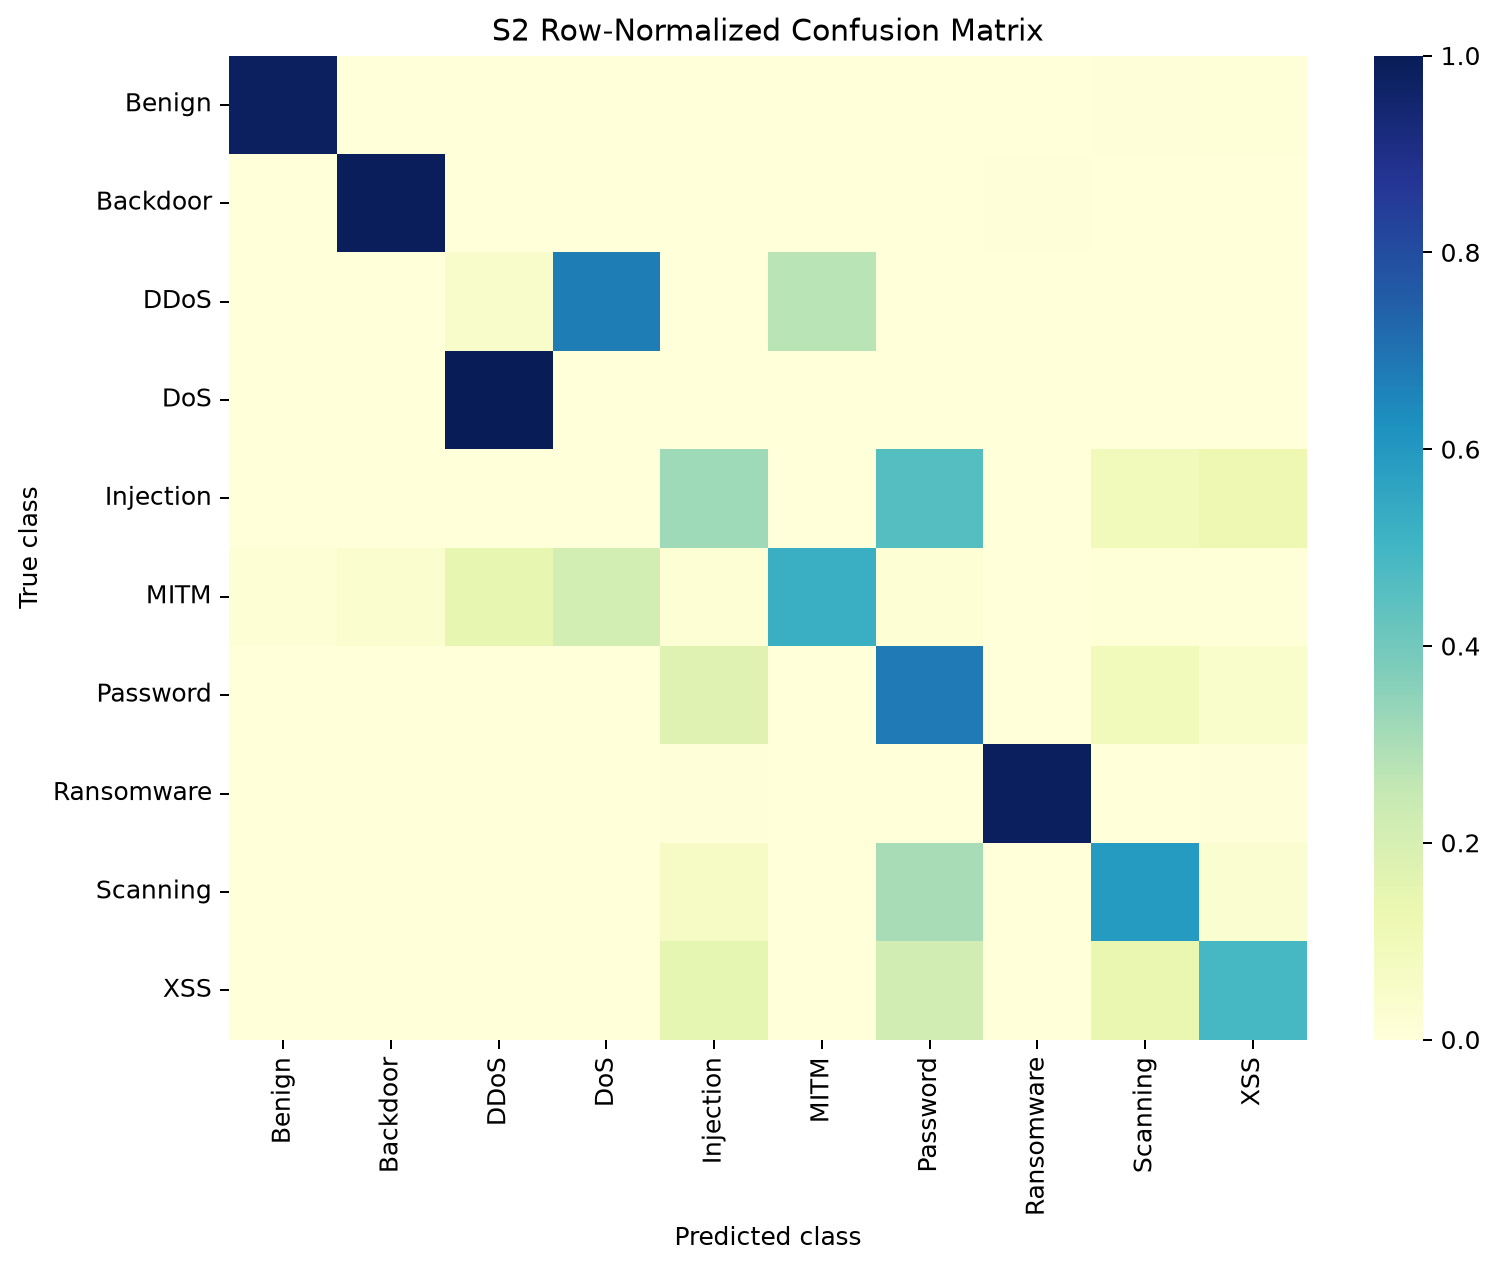

### Figure 4.5 - Latent vs Original-Feature Baseline

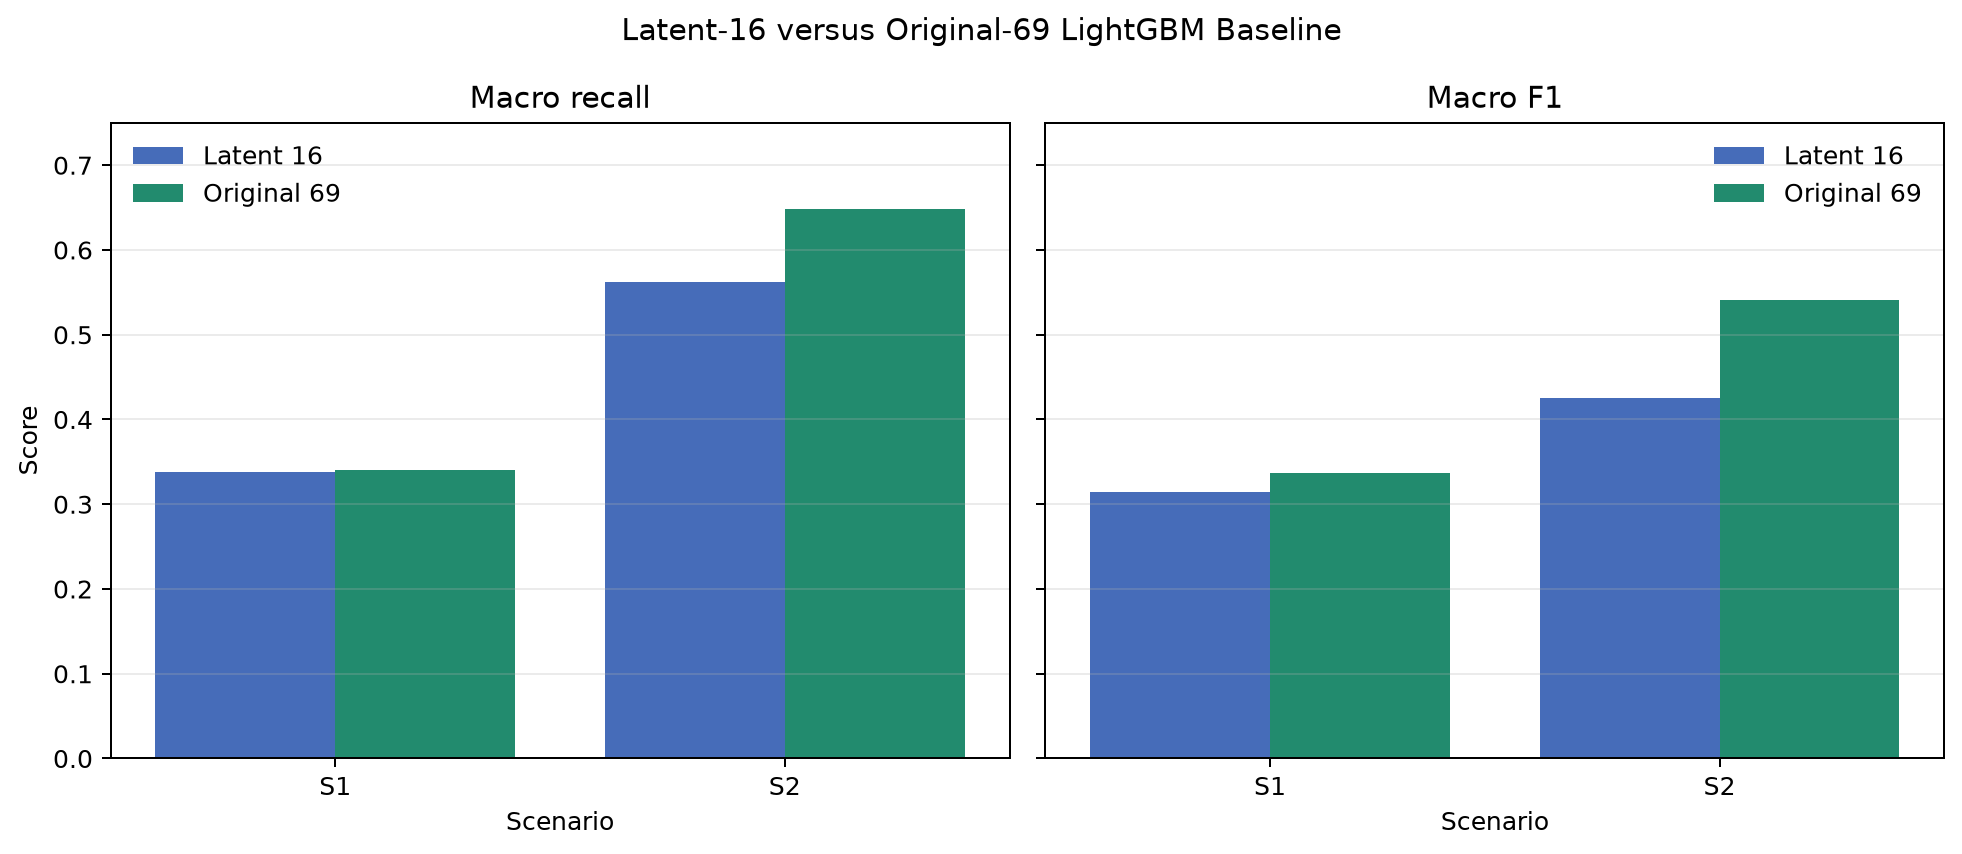

In [5]:
# Cell 5 - Preview every figure generated for the Chapter IV draft.
figure_titles = {
    'autoencoder_loss': 'Figure 4.1 - Autoencoder Training and Validation Loss',
    'scenario_metrics': 'Figure 4.2 - Aggregate Scenario Metrics',
    'minority_f1': 'Figure 4.3 - Minority-Class F1-Scores',
    's2_confusion': 'Figure 4.4 - S2 Confusion Matrix',
    'representation_baseline': 'Figure 4.5 - Latent vs Original-Feature Baseline',
}

for figure_key, figure_title in figure_titles.items():
    figure_path = Path(report_result['figure_paths'][figure_key])
    assert figure_path.exists(), f'Missing figure: {figure_path}'
    display(Markdown(f'### {figure_title}'))
    display(Image(filename=str(figure_path)))

In [6]:
# Cell 6 - Validate full-data provenance and all generated deliverables.
with open(report_result['manifest_path'], 'r', encoding='utf-8') as file:
    manifest = json.load(file)

assert manifest['full_data_only'] is True
assert manifest['quick_run_artifacts_excluded'] is True
assert manifest['test_artifacts_unchanged'] is True
assert manifest['optional_baseline_included'] is True
assert manifest['hypothesis_assessments'] == {
    'H1': 'Supported methodologically',
    'H2': 'Partially supported',
    'H3': 'Supported',
}
assert all(Path(path).exists() for path in report_result['table_paths'].values())
assert all(Path(path).exists() for path in report_result['figure_paths'].values())

print('Phase 9 provenance and deliverable checks passed.')

Phase 9 provenance and deliverable checks passed.


# Chapter IV Draft - Results and Discussion

> **Data provenance.** Every primary value in this draft is generated from the full-data artifacts in `results/metrics`. Quick-run artifacts are explicitly rejected by `src/reporting.py` and must not be reported as thesis results.

## 4.1 Experimental Data and Preprocessing

The raw dataset contained 5,351,760 rows. Preprocessing removed 1,177 rows with invalid numeric values, leaving 5,350,583 valid observations and 69 model features. The stratified 80:20 split produced 4,280,466 training rows and 1,070,117 test rows. The maximum class-percentage difference between the two splits was 0.000047 percentage points.

The scaler was fitted only on training rows (`scaler_fit_scope = train_only`) and then applied unchanged to both splits. Resampling and class weighting were applied only to training artifacts, while the classifier integrity report verified that test artifacts remained unchanged. These controls support H1 methodologically: they demonstrate the intended ordering and reduce leakage risk, but they do not claim that leakage prevention is itself an empirical performance gain.

See [Table 4.1](tables/table_4_1_dataset_pipeline.csv).

## 4.2 Autoencoder Training and Latent Representation

The Autoencoder reduced 69 normalized features to 16 latent features, a 76.81% dimension reduction. The selected checkpoint was epoch 48 with validation MSE 0.00010914. Full-array reconstruction MSE was 0.00011259 on train and 0.00011357 on test, a relative gap of 0.87%. The small gap indicates no coarse reconstruction overfitting.


**Autoencoder loss**

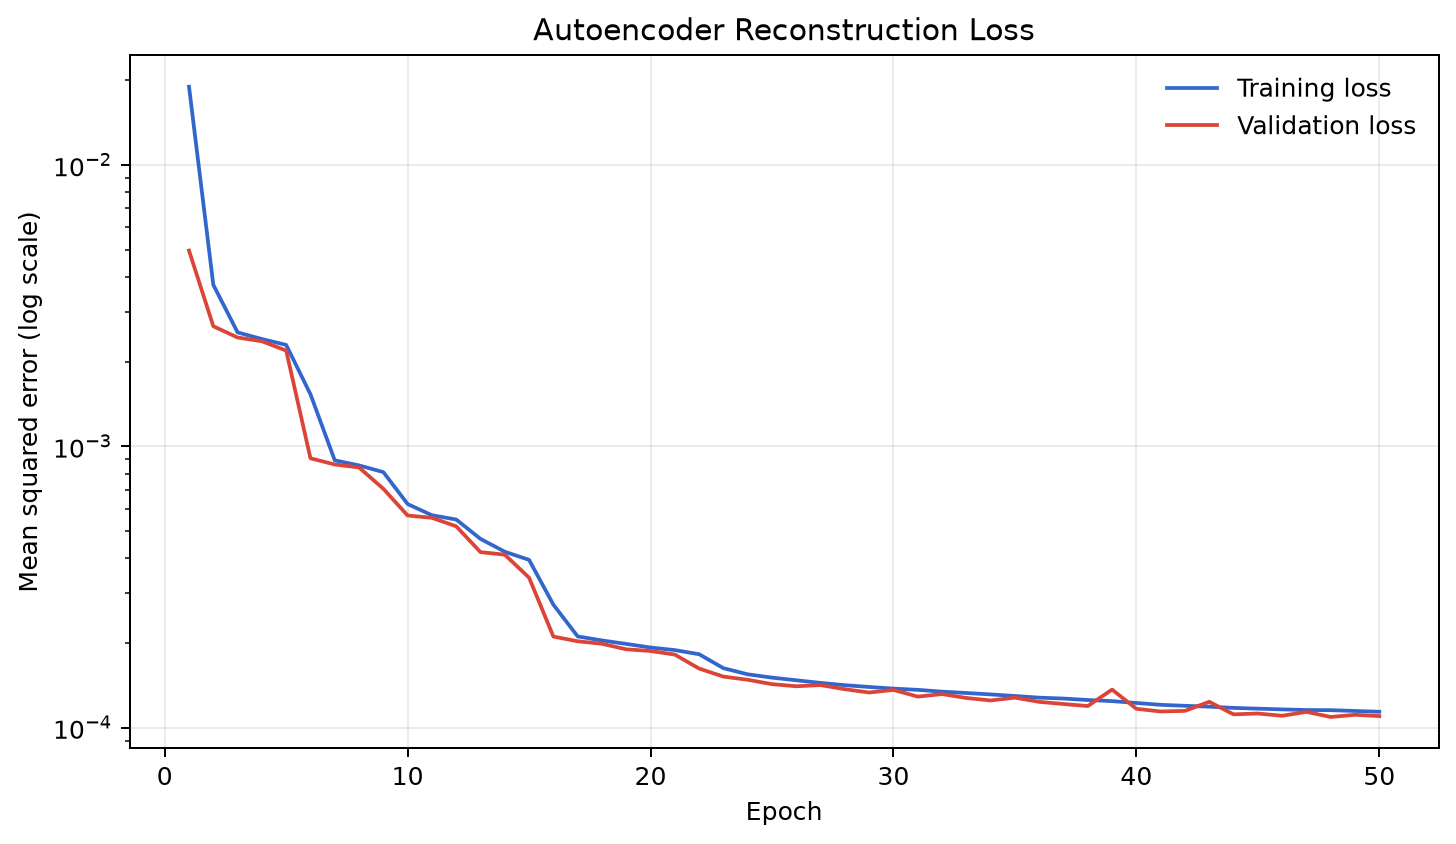


## 4.3 Imbalance-Handling Scenario Results

| Scenario | Accuracy | Macro precision | Macro recall | Macro F1 | Training seconds |
|---|---|---|---|---|---|
| S1 - No handling | 0.8436 | 0.3204 | 0.3376 | 0.3142 | 104.9755 |
| S2 - Class weight | 0.7285 | 0.4106 | 0.5620 | 0.4249 | 104.9128 |
| S3 - Upsampling | 0.7278 | 0.4103 | 0.5580 | 0.4233 | 532.1799 |
| S4 - Downsampling | 0.6155 | 0.3050 | 0.4900 | 0.2923 | 1.6365 |

S1 achieved the highest accuracy (0.8436) but only 0.3142 macro F1. S2 achieved the best macro recall (0.5620) and macro F1 (0.4249). S3 was nearly equivalent to S2, differing by only 0.0017 macro F1 while requiring 5.07 times the classifier training time. This similarity is consistent with random duplication and class weighting producing equivalent relative class contributions for tree training. S4 produced the lowest aggregate macro F1 (0.2923) after discarding nearly all majority-class training rows.


**Scenario metrics**

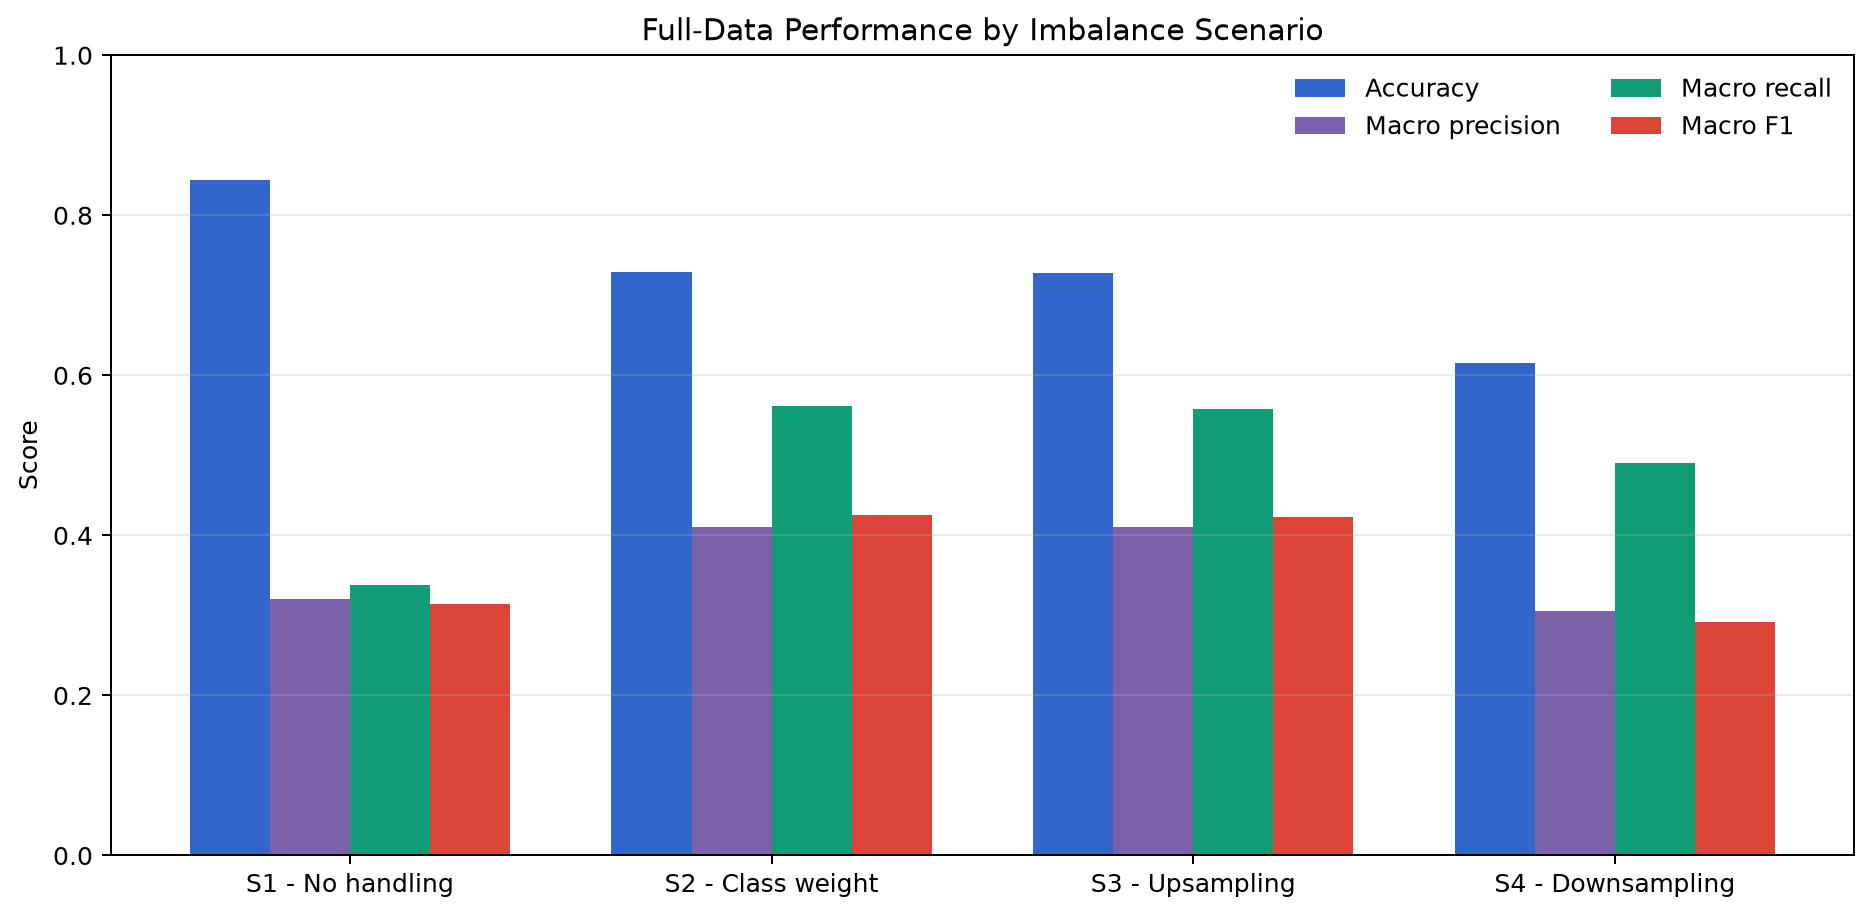


## 4.4 Per-Class Effects and Confusion Patterns

The imbalance strategies improved several minority classes but did not improve every class. Backdoor and Ransomware benefited strongly under S2/S3, while DoS and DDoS remained unreliable in all four scenarios. The complete focus-class values are provided in [Table 4.4](tables/table_4_4_minority_class_metrics.csv).

The trade-off was substantial for XSS: recall fell from 0.9241 under S1 to 0.4898 under S2. Therefore, S2 is the preferred scenario under the pre-specified macro-metric objective, not a universal winner for every class or operating requirement.


**Minority F1**

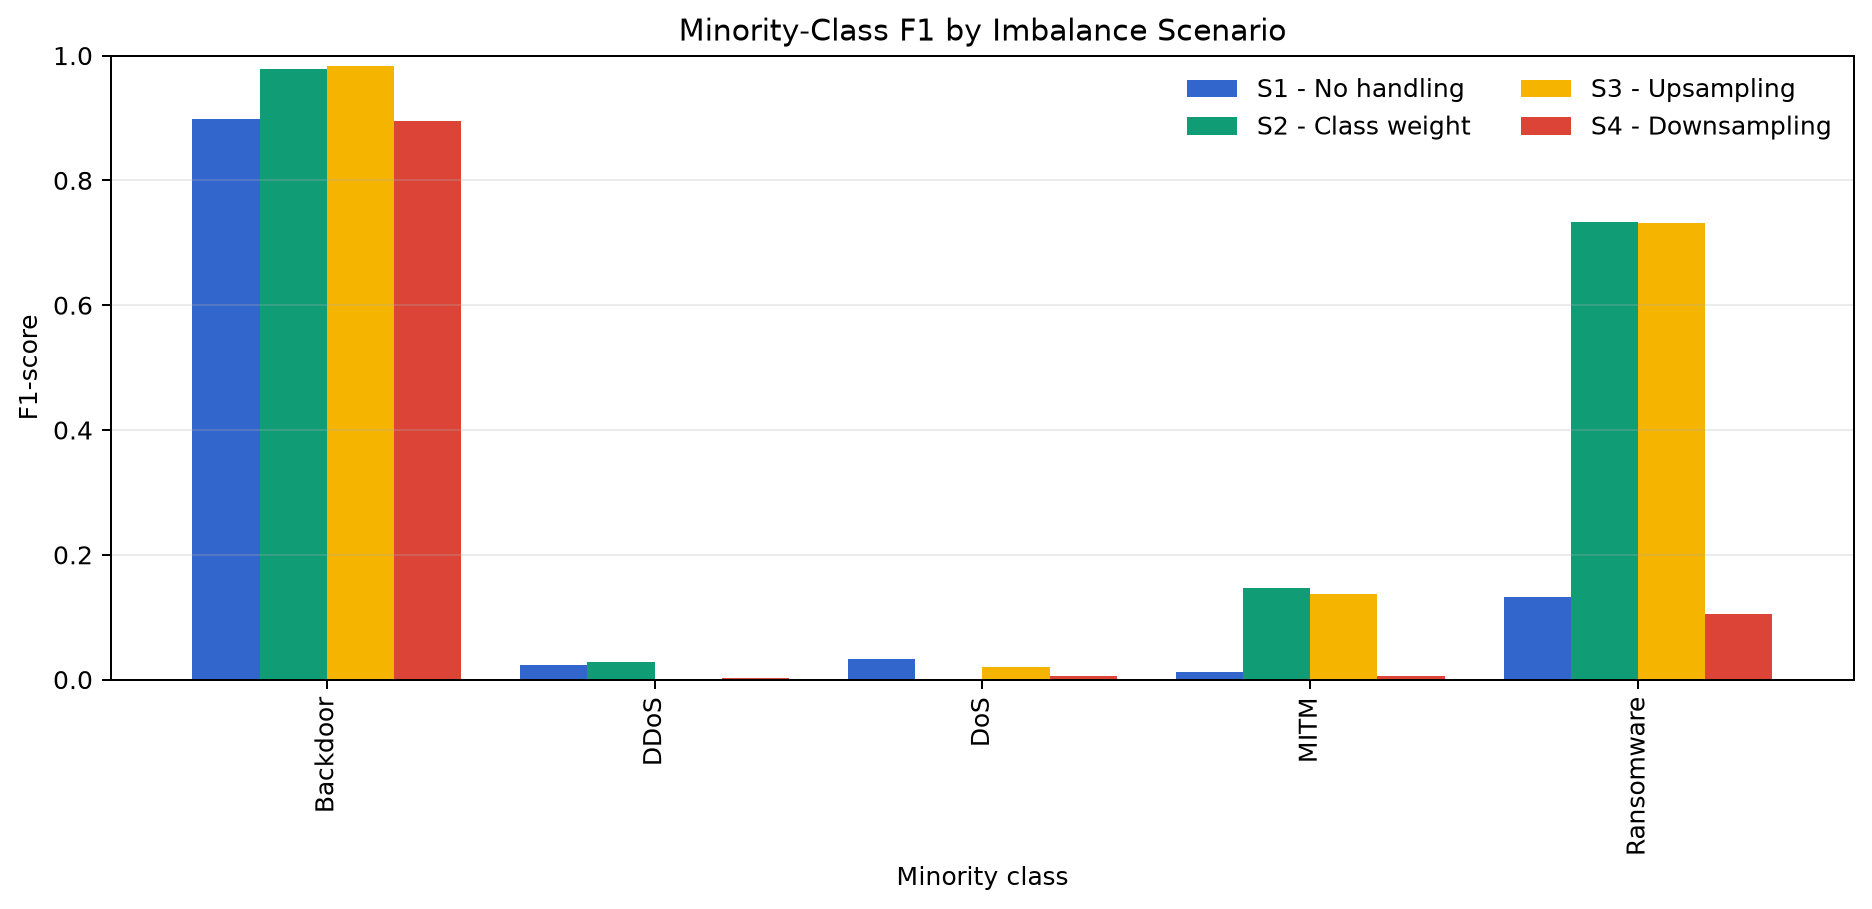

**S2 confusion matrix**

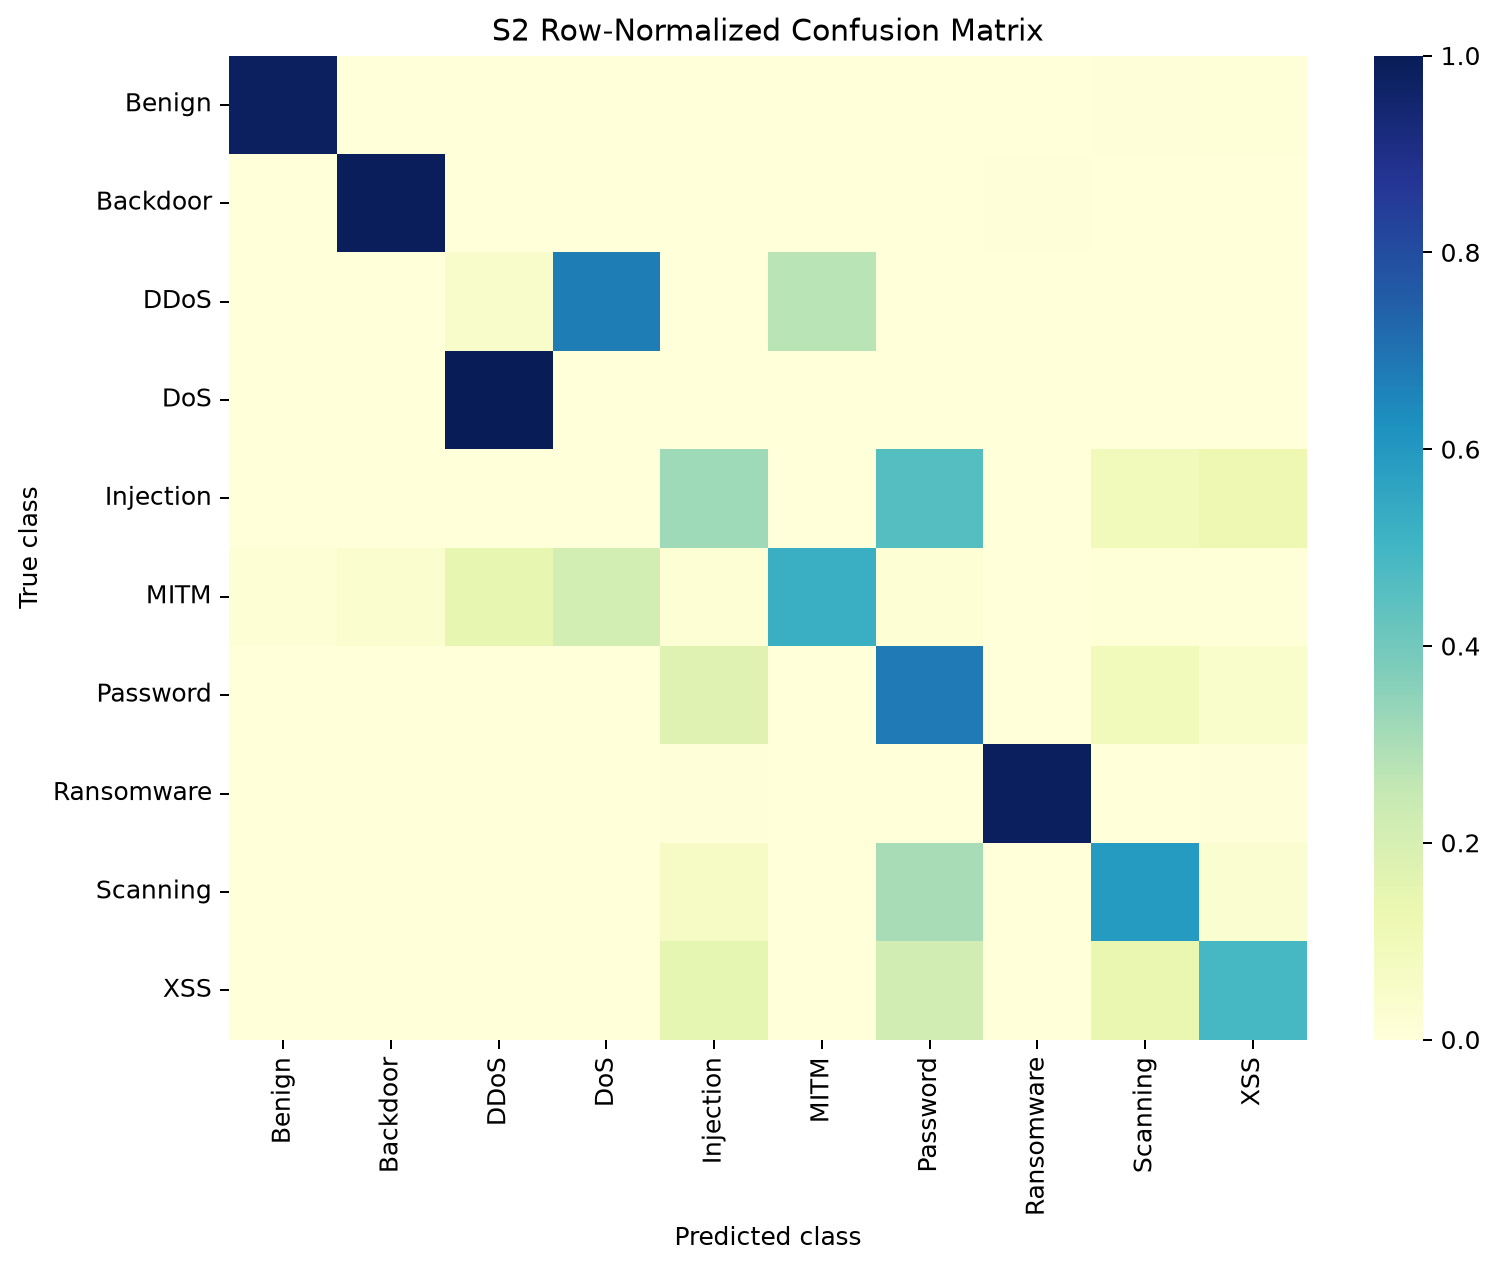


## 4.5 Optional Original-Feature Baseline and H2

| Representation | Scenario | Accuracy | Macro recall | Macro F1 | Classifier seconds |
|---|---|---|---|---|---|
| latent_16 | s1_none | 0.8436 | 0.3376 | 0.3142 | 104.9755 |
| latent_16 | s2_class_weight | 0.7285 | 0.5620 | 0.4249 | 104.9128 |
| original_69 | s1_none | 0.8531 | 0.3401 | 0.3373 | 243.9785 |
| original_69 | s2_class_weight | 0.7881 | 0.6483 | 0.5406 | 208.4351 |

Under S2, the original 69-feature baseline improved macro F1 by 0.1157 (0.4249 to 0.5406) and improved macro recall from 0.5620 to 0.6483. In contrast, the latent representation reduced LightGBM training time by 49.7% for S2. This timing comparison covers the classifier only and must not be interpreted as an end-to-end runtime advantage because Autoencoder training is an additional cost.

H2 is therefore partially supported. The Autoencoder clearly provides a compact representation from which LightGBM can distinguish several classes, but the controlled baseline shows that the 16-dimensional representation does not preserve all useful discriminative information. It should not be claimed that the Autoencoder improves classification performance over the original features.

For DoS and DDoS, the original-feature baseline did not improve the best F1 for either class. This supports the diagnostic conclusion that their failure is not primarily an Autoencoder artifact: The original 69 features improve S2 macro F1 from 0.4249 to 0.5406, but they do not improve the best attainable F1-score for either DoS or DDoS. Their mutual confusion is therefore more consistent with intrinsic flow similarity and very small class supports than with Autoencoder information loss as the primary cause.


**Representation baseline**

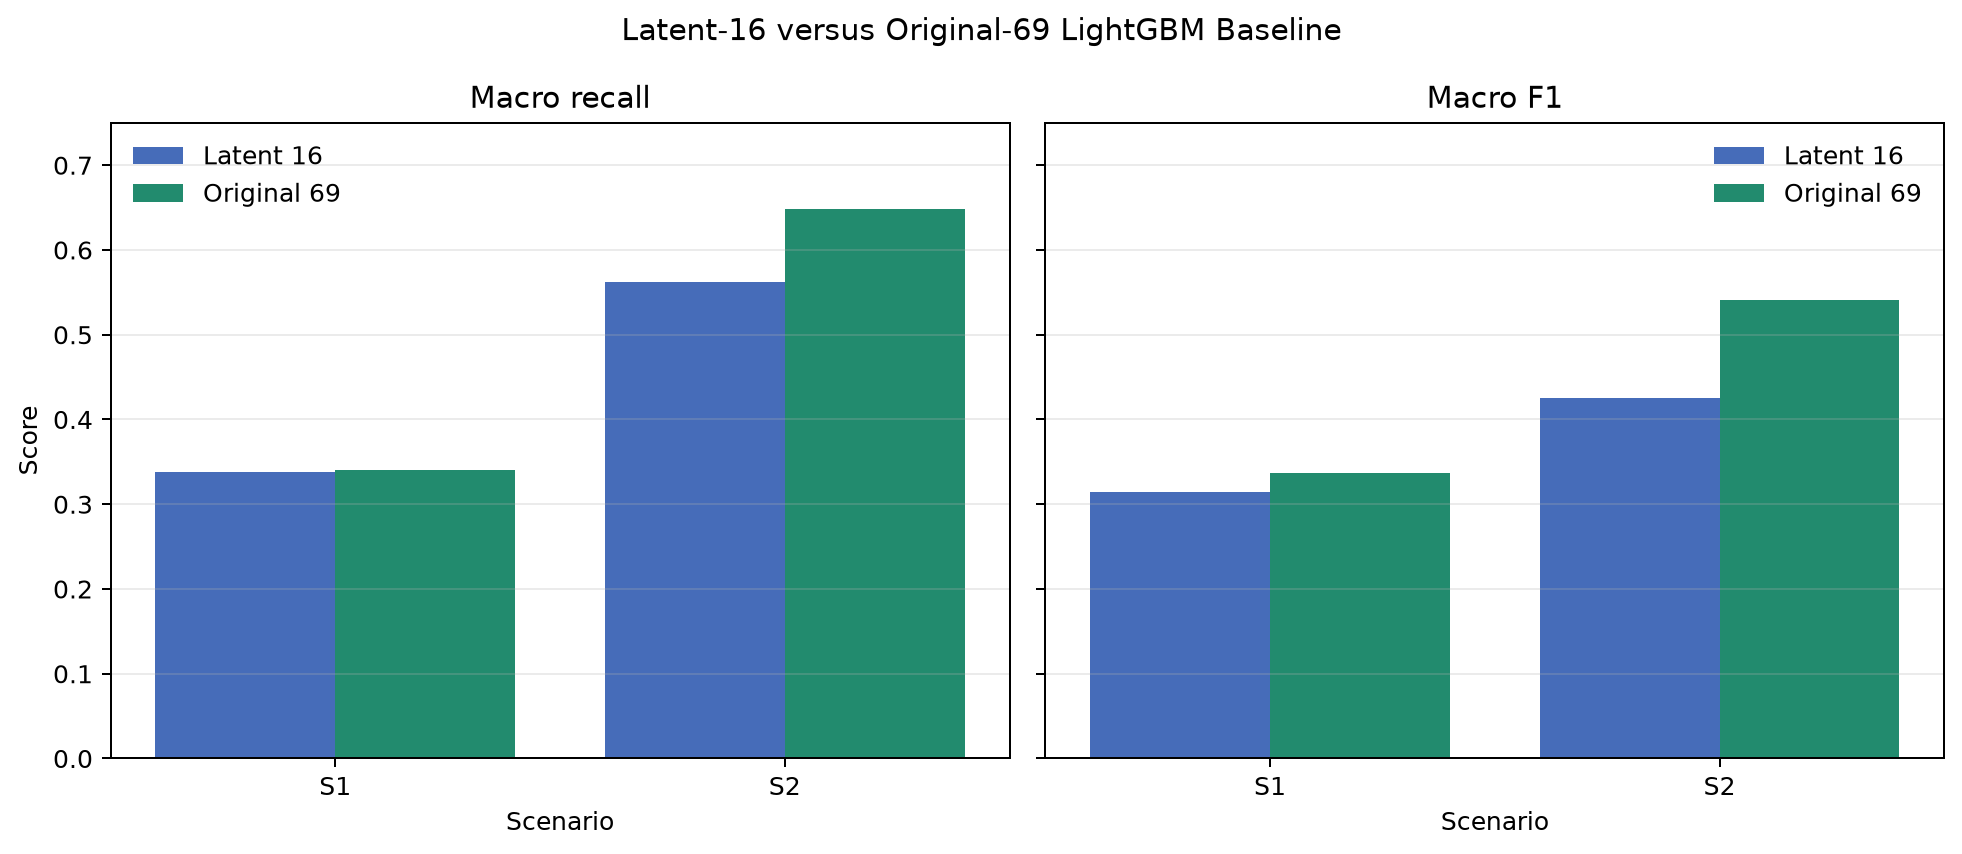


## 4.6 Hypothesis Assessment

| hypothesis | assessment | evidence |
|---|---|---|
| H1 | Supported methodologically | Split precedes normalization; scaler scope is train_only; imbalance handling uses training artifacts; test integrity hashes remain unchanged. |
| H2 | Partially supported | Latent-16 reduces dimension by 76.81% and remains classifiable, but original-69 S2 macro F1 is 0.5406 versus 0.4249 for latent-16. |
| H3 | Supported | S1 has the best accuracy, while S2 has the best macro recall/F1; per-class recall and confusion change materially across scenarios. |

H3 is supported because imbalance handling materially changed macro recall, macro F1, and class-level confusion. The contrast between S1 accuracy and S2 macro performance also confirms that accuracy alone is insufficient for this dataset.

## 4.7 Supplementary Diagnostics

A post-hoc data-quality audit found 145 byte-identical DoS/DDoS feature groups with contradictory labels. All 145 DoS rows were involved, together with 71.78% of DDoS rows. This label contradiction provides a direct explanation for persistent mutual confusion and must be stated as a dataset limitation.

The exploratory Autoencoder sensitivity study reached its best macro F1 (0.4395) with v4_linear_32_weighted. This remains below the original-69 S2 baseline and is supplementary rather than a replacement for the pre-registered latent-16 pipeline.

Within the proposal's LightGBM sensitivity grid, the strongest latent-16 point was learning_rate=0.05 and n_estimators=200 with macro F1 0.4249. Because these sensitivity values were evaluated on the held-out test set, they are descriptive and must not be used as post-hoc test-set model selection.

A separate nine-class diagnostic merged DoS and DDoS to remove the contradictory decision boundary. Its S2 macro F1 was 0.5136. This value is not directly comparable with the primary ten-class metrics and must remain a supplementary dataset-correction experiment.

## 4.8 Limitations

- DoS and DDoS have extremely small support and contradictory duplicate labels.
- S3 uses random duplication, so its effective class contribution is mathematically close to S2 while requiring substantially more storage and training time.
- S4 removes 99.97% of training rows and is intentionally an extreme comparison.
- The original-feature baseline improves predictive metrics, so dimensionality reduction should be justified by compactness and classifier cost, not accuracy gain.
- Exploratory variant and tuning results are sensitivity analyses, not confirmation from an independent second test set.
- Quick-run metrics are smoke-test outputs and are excluded from every table and conclusion in this chapter.

## 4.9 Chapter Conclusion

The experiment supports the leakage-aware preprocessing procedure in H1 and the imbalance-sensitivity claim in H3. H2 is partially supported: latent-16 is compact and useful, but the optional original-69 baseline is stronger under the primary macro metrics. S2 class weighting is the preferred ten-class latent scenario for macro recall and macro F1, while S1 remains preferable only when aggregate accuracy is prioritized over balanced class performance.

## Generated Materials

- `tables/`: CSV tables for direct import into the thesis source.
- `figures/`: full-data PNG figures at 180 DPI.
- `report_manifest.json`: machine-readable provenance and hypothesis conclusions.

In [7]:
# Cell 7 - Render the complete Chapter IV draft with local figures resolved correctly.
def display_markdown_with_local_images(markdown_text, base_dir):
    pending_lines = []

    def display_pending_markdown():
        if pending_lines:
            display(Markdown('\n'.join(pending_lines)))
            pending_lines.clear()

    for line in markdown_text.splitlines():
        if line.startswith('![') and '](' in line and line.endswith(')'):
            display_pending_markdown()
            alt_text, relative_path = line[2:-1].split('](', maxsplit=1)
            image_path = (base_dir / relative_path).resolve()
            if not image_path.exists():
                raise FileNotFoundError(f'Missing report image: {image_path}')
            display(Markdown(f'**{alt_text}**'))
            display(Image(filename=str(image_path)))
        else:
            pending_lines.append(line)

    display_pending_markdown()


draft_path = Path(report_result['draft_path'])
draft_text = draft_path.read_text(encoding='utf-8')
assert 'Quick-run artifacts are explicitly rejected' in draft_text
assert 'H2 is therefore partially supported' in draft_text
display_markdown_with_local_images(draft_text, draft_path.parent)